In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import scale

In [2]:
iris=load_iris()
data, targets = scale(iris.data), iris.target

In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
y = pca.fit_transform(data)

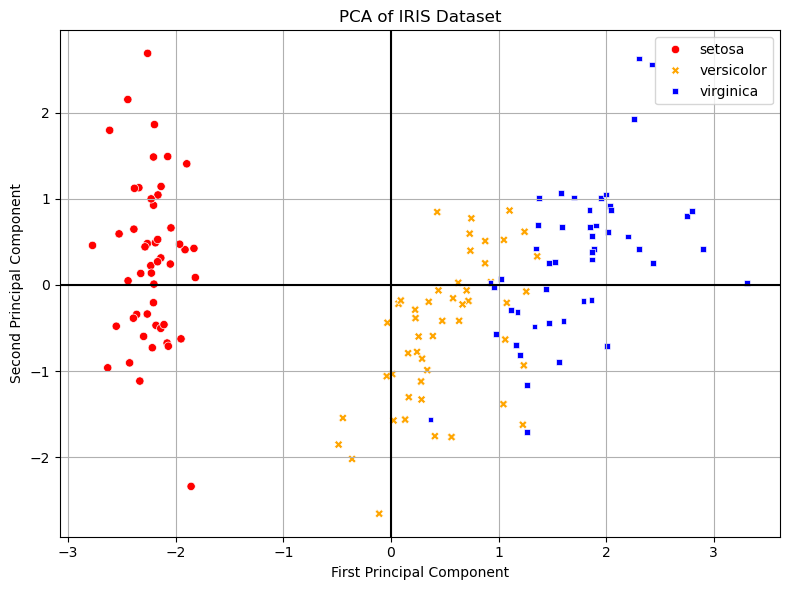

Confusion Matrix:
 [[19  0  0]
 [ 0 10  3]
 [ 0  1 12]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.91      0.77      0.83        13
   virginica       0.80      0.92      0.86        13

    accuracy                           0.91        45
   macro avg       0.90      0.90      0.90        45
weighted avg       0.92      0.91      0.91        45



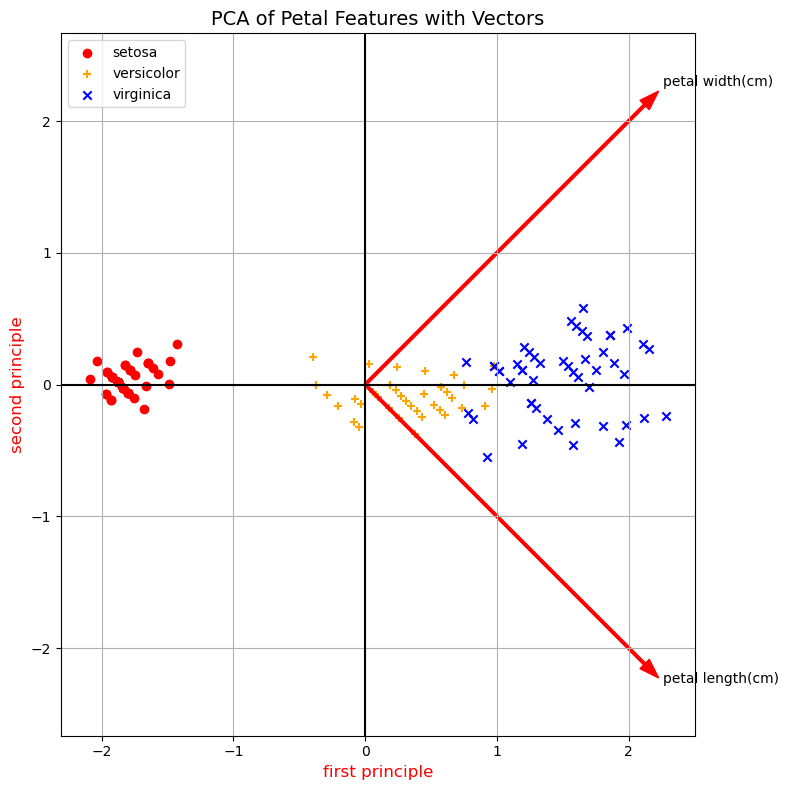

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. 載入 iris 資料集
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 2. 所有特徵 PCA
X_std = StandardScaler().fit_transform(X)
pca_all = PCA(n_components=2)
X_pca_all = pca_all.fit_transform(X_std)

df_pca_all = pd.DataFrame(X_pca_all, columns=["PC1", "PC2"])
df_pca_all["target"] = y
df_pca_all["target_name"] = df_pca_all["target"].apply(lambda i: target_names[i])

# 3. 繪製上半圖：全部特徵的 PCA 結果
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca_all, x="PC1", y="PC2",
                hue="target_name", style="target_name",
                palette=["red", "orange", "blue"])
plt.title("PCA of IRIS Dataset")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 4. 分類：邏輯回歸
X_train, X_test, y_train, y_test = train_test_split(X_pca_all, y, test_size=0.3, random_state=42)
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 5. 印出評估指標
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# 6. 下半圖：僅使用 petal features（花瓣長寬）做 PCA
petal_indices = [2, 3]
X_petal = X[:, petal_indices]
X_petal_std = StandardScaler().fit_transform(X_petal)

pca_petal = PCA(n_components=2)
X_petal_pca = pca_petal.fit_transform(X_petal_std)

components = pca_petal.components_

# 7. 繪製下半圖
plt.figure(figsize=(8, 8))
colors = ['red', 'orange', 'blue']
markers = ['o', '+', 'x']

for i, target_name in enumerate(target_names):
    plt.scatter(X_petal_pca[y == i, 0], X_petal_pca[y == i, 1],
                label=target_name, color=colors[i], marker=markers[i])

# 畫出主成分方向箭頭
for i, label in enumerate(['petal length(cm)', 'petal width(cm)']):
    plt.arrow(0, 0, components[0, i]*3, components[1, i]*3,
              color='red', width=0.02, head_width=0.1)
    plt.text(components[0, i]*3.2, components[1, i]*3.2, label, color='black')

# 坐標軸與圖例
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('first principle', fontsize=12, color='red')
plt.ylabel('second principle', fontsize=12, color='red')
plt.title('PCA of Petal Features with Vectors', fontsize=14)
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()
